In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

Identyfikacja portfeli niepracujących oraz estymacja prawdopodobieństwa ich wystąpienia
==============

**Joanna Pokora**

## Wstęp

Celem raportu jest analiza danych kredytowych pod kątem portfeli niepracujących. W pierwszej kolejności zidentyfikowane zostaną portfele niepracujące, a następnie wyznaczone zostaną obserwowane odsetki niewykonania zobowiązania w dwunastomiesięcznych przedziałach czasowych. Ponadto, oszacowane zostaną prawdopodobieństwa wystąpienia portfela niepracującego w ciągu kolejnych dwunastu miesięcy dla różnych grup ryzyka.

## Przygotowanie danych

Dane użyte w raporcie pochodzą z dwóch tabel. Pierwsza z nich zawiera informacje kredytowe:

* id_kredytu - identyfikator kredytu,
* period_dte - data końca okresu,
* start_bal_amt - początkowa kwota kredytu,
* start_dte - data uruchomienia kredytu,
* bal_amt - kwota pozostała do spłaty,
* kwota_przeterm - kwota przeterminowana,
* dpd - liczba dni z jakimkolwiek przeterminowaniem,
* fl_windykacji - oznaczenie rachunkó windykowanych,
* fl_smierc - oznaczenie śmierci kredytobiorców,
* ttm - liczba lat do końca kredytu.

Druga tabela zawiera dane o przeterminowaniach:

* id_kredytu,
* period_dte,
* dma - liczba dni z przeterminowaniem powyżej 400 zł i powyżej 1% wartości ekspozycji.

In [2]:
df_kredyty = pd.read_parquet("C:/Users/Baller/Desktop/magisterka/bankowosc/raport3/dane_lista3/kredyty.parquet")
df_dma = pd.read_parquet("C:/Users/Baller/Desktop/magisterka/bankowosc/raport3/dane_lista3/DMA.parquet")

df_kredyty.period_dte = pd.to_datetime(df_kredyty.period_dte)
df_dma.period_dte = pd.to_datetime(df_dma.period_dte)

W obu tabelach wiele wierszy może dotyczyć tego samego kredytu, przy czym każdy z nich reprezentuje inny miesięczny okres. Dane łączymy zatem na podstawie identyfikatora kredytu oraz nowej kolumny period_id, postaci 12*rok+miesiąc, gdzie rok i miesiąc wyznaczane są z daty zakończenia danego okresu.

In [3]:
df_kredyty['period_id'] = 12*df_kredyty.period_dte.dt.year + df_kredyty.period_dte.dt.month

In [4]:
df_dma['period_id'] = 12*df_dma.period_dte.dt.year + df_dma.period_dte.dt.month

In [5]:
df_kredyty = pd.merge(left=df_kredyty, right=df_dma[['period_dte','id_kredytu', 'dma']], left_on=['id_kredytu', 'period_dte'], right_on=['id_kredytu', 'period_dte'], how='left')

Po połączeniu danych uzyskujemy 80 wierszy z brakującymi wartościami w kolumnie dma, które nie będą branę pod uwagę w dalszych analizach. Ostateczny zbiór zawiera więc 100862 obserwacji oraz 4917 unikalnych portfeli kredytowych.

## Identyfikacja portfeli niepracujących

Portfel klasyfikowany jest jako niepracujący, jeśli spełniony jest co najmniej jeden z poniższych warunków:

* rachunek znajduje się w windykacji (fl_windykacji = 1),
* liczba dni z przeterminowaniem powyżej 400 zł oraz powyżej 1% wartości ekspozycji (DMA) przekracza 90 dni,
* nastąpiła śmierć wszystkich kredytobiorców (fl_smierc = 1).

Zgodnie z tą definicją identyfikujemy obserwacje będące portfelami niepracującymi oraz oznaczamy je w nowej kolumnie fl_npl.

In [6]:
df_kredyty['fl_npl'] = 0
df_kredyty.loc[df_kredyty.fl_windykacji == 1, 'fl_npl'] = 1
df_kredyty.loc[df_kredyty.dma > 90, 'fl_npl'] = 1
df_kredyty.loc[df_kredyty.fl_smierc == 1, 'fl_npl'] = 1

Aby portfel mógł zostać ponownie sklasyfikowany jako pracujący, musi posiadać prawidłową obsługę w trzecim miesiącu od momentu niespełnienia definicji portfela niepracującego. Dopiero w czwartym miesiącu może on zostać formalnie oznaczony jako pracujący.

Poniższa pętla sprawdza prawidłową obsługę trzy miesiące po każdym zakończonym okresie oznaczenia portfela jako niepracujący, jednocześnie nadając mu w każdym z trzech kolejnych miesięcy status niepracującego. Ostateczne oznaczenia zapisywane są w kolumnie fl_npl_adj.

In [7]:
df_kredyty = df_kredyty.loc[df_kredyty.dma.isna() == False, :].copy()

In [8]:
df_kredyty["fl_npl_adj"] = df_kredyty["fl_npl"].copy()

In [9]:
kredyty_default_ever = df_kredyty.loc[df_kredyty.fl_npl > 0, "id_kredytu"].drop_duplicates().to_list()

In [10]:
for kred in kredyty_default_ever:
    df_kred_jeden = df_kredyty.loc[df_kredyty.id_kredytu == kred, :].sort_values("period_id").copy()
    df_kred_jeden["fl_npl_shifted"] = df_kred_jeden["fl_npl"].shift(fill_value = 0)

    period_wejscie_default = df_kred_jeden.loc[(df_kredyty.fl_npl == 1) & (df_kred_jeden.fl_npl_shifted == 0), "period_id"].to_list()

    max_hist_per = df_kred_jeden.loc[(df_kredyty.id_kredytu == kred), "period_id"].max()

    for i in period_wejscie_default:
        while i <= max_hist_per:
            if df_kredyty.loc[(df_kredyty.id_kredytu == kred) & (df_kredyty.period_id == i), "fl_npl"].values[0] == 1:
                i += 1
            else:
                j = i

                while (j < i+3) and (j != max_hist_per + 1):
                    df_kredyty.loc[(df_kredyty.id_kredytu == kred) & (df_kredyty.period_id == j), "fl_npl_adj"] = 1
                    j += 1

                if j > max_hist_per:
                    i = j + 1
                else:
                    if(df_kredyty.loc[(df_kredyty.id_kredytu == kred) & (df_kredyty.period_id == j), "fl_npl"].values[0] == 0) & (df_kredyty.loc[(df_kredyty.id_kredytu == kred) & (df_kredyty.period_id == j), "dma"].values[0] <= 30):
                        i = max_hist_per + 1
                    else:
                        df_kredyty.loc[(df_kredyty.id_kredytu == kred) & (df_kredyty.period_id == j), "fl_npl_adj"] = 1
                        i = j + 1

Poniżej przedstawione zostały zliczenia portfeli oznaczonych jako pracujące oraz niepracujące.

In [11]:
df_kredyty.fl_npl.value_counts(dropna = False)

0    95262
1     5600
Name: fl_npl, dtype: int64

In [12]:
df_kredyty.fl_npl_adj.value_counts(dropna = False)

0    95081
1     5781
Name: fl_npl_adj, dtype: int64

Całkowity odsetek obserwacji reprezentujących niepracujące portfele wyniósł w przybliżeniu 6%.

## Obserwowane odsetki niewykonania zobowiązań

W kolejnym kroku wyznaczony zostanie obserwowany odsetek niewykonania zobowiązań w ciągu kolejnych 12 miesięcy od zakończenia każdego okresu. Portfele, które dla danego okresu nie posiadają pełych informacji (z 12 miesięcy), nie będą brane pod uwagę.

In [13]:
df_kredyty_default = df_kredyty[['id_kredytu', 'period_id', 'fl_npl_adj']].copy()

In [14]:
for i in range(1, 13):
    df_kredyty_default['period_id_plus_' + str(i)] = df_kredyty_default.period_id + i
    
    pom = df_kredyty_default[['period_id', 'id_kredytu', 'fl_npl_adj']].copy()  
    pom = pom.rename(columns = {'fl_npl_adj': 'fl_npl_' + str(i), 'period_id': 'period_id_def_' + str(i)})

    df_kredyty_default = pd.merge(left = df_kredyty_default, 
                          right=pom, 
                          left_on=['id_kredytu', 'period_id_plus_' + str(i)], 
                          right_on=['id_kredytu', 'period_id_def_' + str(i)],                        
                          how='left')

In [15]:
df_kredyty_default['sum_def'] = df_kredyty_default[['fl_npl_' + str(i) for i in range(1, 13)]].sum(axis=1).apply(lambda x: 1 if x>0 else 0)
df_kredyty_default['flg_default_def_avaliable'] = df_kredyty_default[['fl_npl_' + str(i) for i in range(1, 13)]].isna().sum(axis=1).apply(lambda x: 0 if x != 0 else 1)

In [16]:
df_kredyty_default["def_12m"] = df_kredyty_default.apply(lambda x: x.sum_def if x.flg_default_def_avaliable == 1 else np.NaN, axis = 1)

In [17]:
df_kredyty = pd.merge(left = df_kredyty,
                     right = df_kredyty_default[["id_kredytu", "period_id", "def_12m"]],
                     left_on = ["id_kredytu", "period_id"],
                     right_on = ["id_kredytu", "period_id"],
                     how = "left")

Poniższy wykres przedstawia zmianę wartości ODR w czasie.

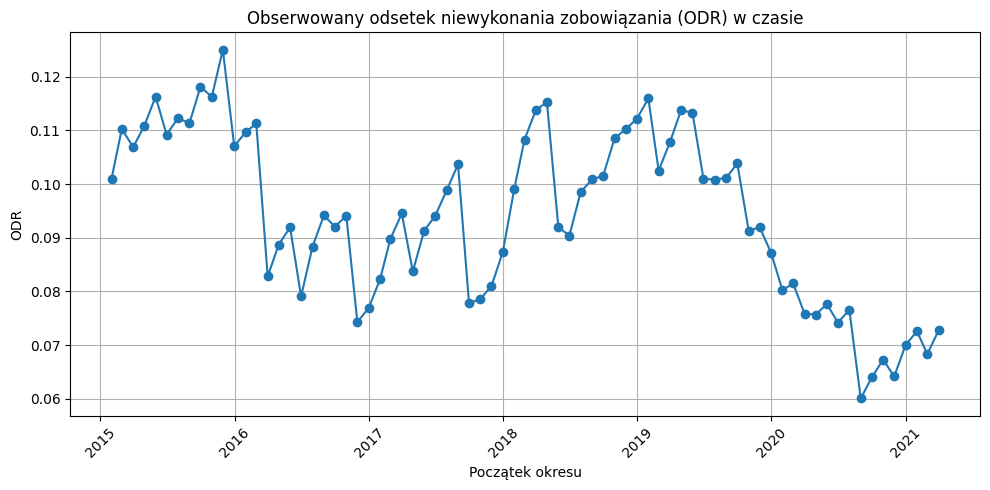

In [21]:
odr_by_period = odr_by_period.sort_values('period_dte')

plt.figure(figsize=(10, 5))
plt.plot(odr_by_period['period_dte'], odr_by_period['def_12m'], marker='o', linestyle='-')

plt.title('Obserwowany odsetek niewykonania zobowiązania (ODR) w czasie')
plt.xlabel('Początek okresu')
plt.ylabel('ODR')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

Spadki wartości ODR zaobserwować można po 2015 roku oraz w okolicach 2019 roku. Najniższy odsetek wystąpił w okresie od września 2020 roku do końca sierpnia 2021 roku, czyli w trakcie trwania pandemii.

## Estymacja prawdopodobieństwa wystąpienia portfela niepracującego

Celem jest estymacja oczekiwanego prawdopodobieństwa wystąpienia portfela niepracującego (PD) w ciągu kolejnych 12 miesięcy. Aby określić różne grupy ryzyka posługujemy się drzewem decyzyjnym, wyznaczonym na podstawie pozostałej kwoty do spłaty.

In [20]:
df_odr = df_kredyty.loc[-df_kredyty.def_12m.isna()]
odr_by_period = df_odr.groupby('period_dte')['def_12m'].mean().reset_index()

In [22]:
X_model = df_kredyty.loc[(df_kredyty.fl_npl_adj == 0) & (df_kredyty.def_12m.isna()==False), ['bal_amt']].reset_index(drop=True)
Y_model = df_kredyty.loc[(df_kredyty.fl_npl_adj == 0) & (df_kredyty.def_12m.isna()==False), ['def_12m']].reset_index(drop=True)

In [23]:
clf = tree.DecisionTreeRegressor(max_depth=2, min_samples_leaf=0.05)
clf = clf.fit(X=X_model, y=Y_model)

In [24]:
X_model['GR'] = pd.Series(clf.apply(X_model))
X_model['def_12m'] = Y_model.copy()

W poniższej tabeli oraz na wykresie przedstawione zostało podsumowanie zbudowanego modelu.

In [25]:
tab = X_model.groupby('GR', as_index=False).agg(COUNT = ('def_12m', 'count'), DEFAULT_COUNT = ('def_12m', 'sum'), PD = ('def_12m', 'mean'))
tab.rename(columns = {"GR": "grupa", "COUNT": "liczba obserwacji", "DEFAULT_COUNT": "liczba obserwacji default"})

,grupa,liczba obserwacji,liczba obserwacji default,PD
0,2,30253,1528.0,0.050507
1,3,17095,1094.0,0.063995
2,4,4593,507.0,0.110385


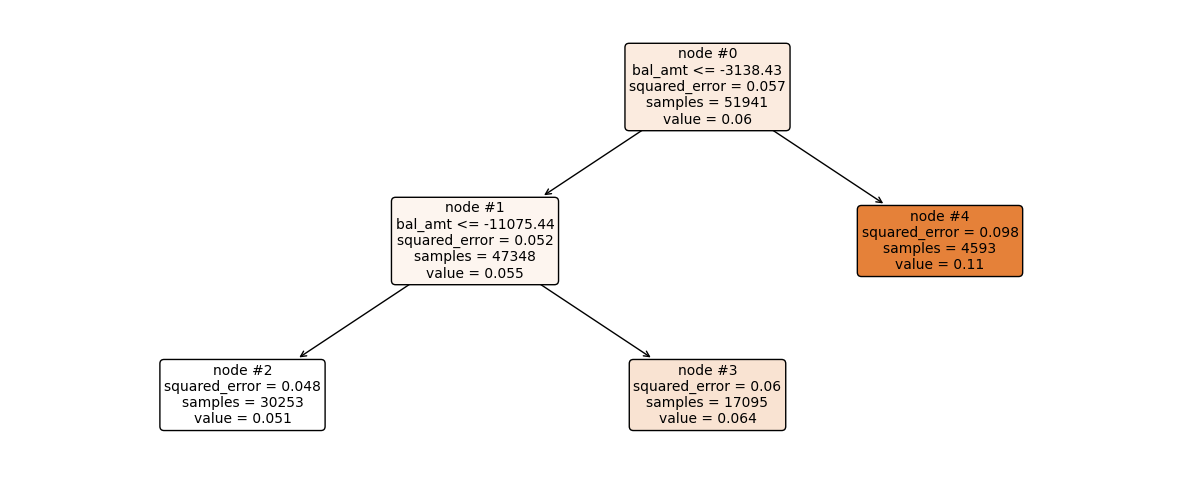

In [26]:
plt.figure(figsize=(15,6))
tree.plot_tree(clf, feature_names = X_model.columns,
              class_names = Y_model.columns, filled = True,
              fontsize = 10,
              node_ids = True,
              impurity = True,
              rounded = True)
plt.show()

Do grupy najmniejszego ryzyka (około 0.051) zakwalifikowane zostały obserwacje, dla których pozostała kwota do spłaty wynosiła nie mniej niż 11075.44 zł, natomiast do grupy z najwyższym ryzykiem (około 0.11) - te, dla których kwota była mniejsza niż 3138.43 zł.

Podział ten jest dość nieintuicyjny, jednak do wyznaczenia grup ryzyka zastosowany został mocno uproszczony model. Aby upewnić się co do jego poprawności, zweryfikujmy rozkład zmiennej bal_amt oznaczającej kwotę pozostałą do spłaty w zależności od portfle

[Text(0.5, 0, 'portfel niepracujący'),
 Text(0, 0.5, 'kwota pozostała do spłaty')]

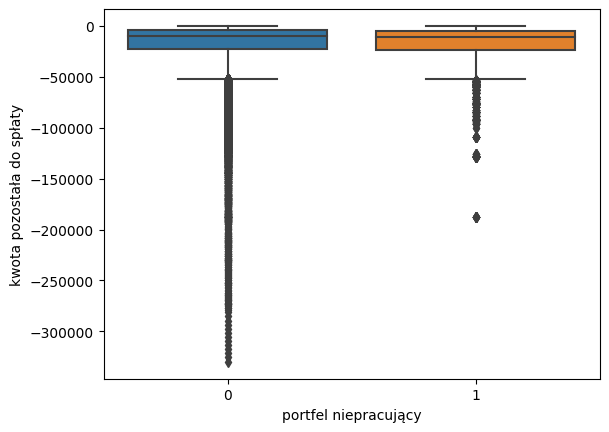

In [27]:
ax = sns.boxplot(x='fl_npl_adj', y='bal_amt', data=df_kredyty)
ax.set(xlabel='portfel niepracujący', ylabel='kwota pozostała do spłaty')

Kwantyle kwot pozostałych do spłaty są bardzo zbliżone zarówno dla portfeli pracujących jak i niepracujących. W przypadku portfeli pracujących obserwujemy jednak znacznie większy rozrzut wartości, co jest zgodne z oczekiwaniami - tuż po uruchomieniu kredytu kwota do spłaty jest wysoka, a takie rachunki rzadko kwalifikowały się jako niepracujące. W związku z tym, zbudowany mode można uznać za poprawny.

## Podumowanie

W raporcie przeprowadzona została identyfikacja portfeli niepracujących - najpierw tych, które spełniały definicję, a następnie tych, które przestały ją spełniać, lecz nadal pozostawały w statusie default przez kolejne trzy miesiące. Następnie wyznaczone zostały obserwowane prawdopodobieństwa niewykonania zobowiązania (ODR) w ciągu kolejnych dwunastu miesięcy od końca każdego miesięcznego okresu.

Ostatnim etapem była estymacja oczekiwanego ODR dla różnych grup ryzyka, wyznaczonych za pomocą drzewa decyzyjnego, zbudowanego na podstawie kwoty pozostałej do spłaty. Dla grupy największego ryzyka, która charakteryzowała się najmniejszą kwotą, prawdopodobieństwo wyniosło około 0.11. Dla grupy o najniższym ryzyku wyniosło ono z kolei około 0.051.